## Apply AIMS4PT Cpx to Merapi

This notebook applies the AIMS4PT clinopyroxene thermobarometry workflow to the Merapi case study, including data preparation, P-T calculation, equilibrium checks, and figure export.


## 1. Setup and Shared Model Pools

### Module and Data Imports

In [1]:
%matplotlib inline

from pathlib import Path
import sys

def _find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")

PROJECT_ROOT = _find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache"
IMAGES_DIR = PAPER_DIR / ".images"
DATA_DIR = PAPER_DIR / "data"
for _dir in (CACHE_DIR, IMAGES_DIR, DATA_DIR):
    _dir.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2
# %matplotlib widget
%matplotlib inline

import pandas as pd
import numpy as np
import sys
import os
import time
import importlib
import matplotlib.pyplot as plt
from aims4pt.model_tools.model_registry import  get_models_initial_pools, print_all_registered_thermobarometry, ALL_MODELS_MODULES
from aims4pt.toolkit_utils import get_file_path
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)



calculate_shap = False # make sure this to False when not needed, as it takes time and memory

timestamp = time.strftime("%Y%m%d_%H%M")
timestamp = "add_pre-2006_020" 
CACHE_DIR = PAPER_DIR / ".cache"/ timestamp
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:


#col names for unseen_experiments_df
cpx_names = ['SiO2_cpx', 'TiO2_cpx', 'Al2O3_cpx',
       'Fe2O3_cpx', 'Cr2O3_cpx', 'FeO_cpx', 'MnO_cpx', 'MgO_cpx', 'NiO_cpx',
       'CoO_cpx', 'CaO_cpx', 'Na2O_cpx', 'K2O_cpx', 'P2O5_cpx',]
liq_names = ['SiO2_liq', 'TiO2_liq', 'Al2O3_liq',
       'Fe2O3_liq', 'Cr2O3_liq', 'FeO_liq', 'MnO_liq', 'MgO_liq', 'NiO_liq',
       'CoO_liq', 'CaO_liq', 'Na2O_liq', 'K2O_liq', 'P2O5_liq']
P_col = 'P (kbar)'
T_col = 'T (C)'


### Initial Thermobarometry Model Pools

In [3]:
P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)


[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [4]:
P_model_dict = {model.model_name: model for model in P_model_pool}
T_model_dict = {model.model_name: model for model in T_model_pool}

In [5]:
unseen_experiments_df_path = os.path.join(DATA_DIR, "independent_data_final.xlsx")
unseen_experiments_df = pd.read_excel(unseen_experiments_df_path)
cpx_unseen = unseen_experiments_df[cpx_names].copy()
liq_unseen = unseen_experiments_df[liq_names].copy()
meta_unseen = unseen_experiments_df[[P_col, T_col]].copy()

testing_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "testing"].index.tolist()
training_unseen_id = unseen_experiments_df[unseen_experiments_df["training/testing"] == "training"].index.tolist()


## 2. Loading and Preparing Merapi Data

In [6]:
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
liq_raw = pd.read_excel(os.path.join(DATA_DIR, "merapi_liq.xlsx"))
liq_raw.columns = liq_raw.columns.str.strip()
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
cpx_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO',
       'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'Cr2O3', 'NiO']
# Set water content (following Scruggs and Putirka, 2018)
# Liq_Comp['H2O_Liq']=Liq_Comp['SiO2_Liq']*0.06995+0.383

In [7]:
PAIRING_CACHE_DIR_04 = PAPER_DIR / ".cache" / "add_pre-2006_028"


def load_passed_cpx_from_pairing_cache(cache_path):
    """Load passed cpx rows saved by 04_apply_AIMS4PT_cpx_to_Merapi."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        raise FileNotFoundError(f"Pairing cache not found: {cache_path}")

    pairs = pd.read_excel(cache_path, sheet_name="pairs")
    mask_df = pd.read_excel(cache_path, sheet_name="pairs_pass_mask")
    cleaned_minerals = pd.read_excel(cache_path, sheet_name="cleaned_minerals")

    mask_values = mask_df["pairs_pass_mask"]
    if mask_values.dtype == object:
        pairs_pass_mask = mask_values.astype(str).str.lower().isin(["true", "1", "yes"])
    else:
        pairs_pass_mask = mask_values.astype(bool)

    pairs_pass_mask.index = pairs.index
    return cleaned_minerals[pairs_pass_mask].reset_index(drop=True)


paired_cpx_06_pass_04 = load_passed_cpx_from_pairing_cache(
    PAIRING_CACHE_DIR_04 / "merapi_2006_pairing_kd028_err1e-4_n20000_endmembers.xlsx"
)
paired_cpx_10_pass_04 = load_passed_cpx_from_pairing_cache(
    PAIRING_CACHE_DIR_04 / "merapi_2010_pairing_kd028_err1e-4_n20000_endmembers.xlsx"
)

cpx_06_input = paired_cpx_06_pass_04.copy()
cpx_10_input = paired_cpx_10_pass_04.copy()

print(f"Loaded cpx_06_input from 04 cache: {len(cpx_06_input)} rows")
print(f"Loaded cpx_10_input from 04 cache: {len(cpx_10_input)} rows")


Loaded cpx_06_input from 04 cache: 42 rows
Loaded cpx_10_input from 04 cache: 106 rows


## 3. Cpx-Liquid Pairing

### Pairing Setup

In [8]:
liq_cols = ['SiO2', 'TiO2',
       'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']


In [9]:
liq_2006 = liq_raw[(liq_raw["Eruption"]==2006) | (liq_raw["Eruption"]=="pre-2006")].reset_index(drop=True)
liq_2010 = liq_raw[(liq_raw["Eruption"]==2010) | (liq_raw["Eruption"]=="pre-2006")].reset_index(drop=True)

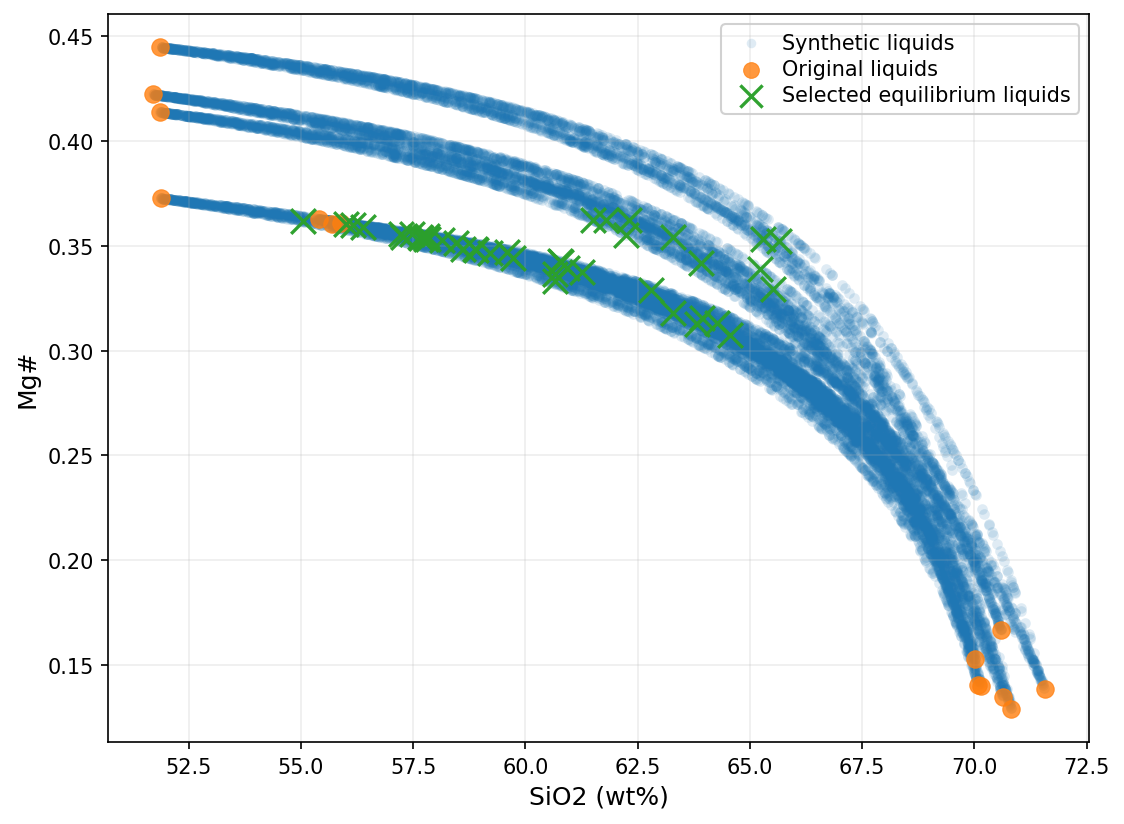

Wrote pairing cache: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\merapi_2006_pairing_err1e-4_n20000_endmembers.xlsx


42

In [10]:
from aims4pt.data_tools.eq_pairing import PairingResult, pair_mineral_liquid_by_kd


def pair_mineral_liquid_by_kd_excel_cache(cache_path, **pairing_kwargs):
    """Run Kd pairing once, then reuse the Excel cache on later notebook runs."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        print(f"Reading cached pairing result: {cache_path}")
        pairs = pd.read_excel(cache_path, sheet_name="pairs")
        mask_df = pd.read_excel(cache_path, sheet_name="pairs_pass_mask")
        cleaned_minerals = pd.read_excel(cache_path, sheet_name="cleaned_minerals")
        cleaned_liquids = pd.read_excel(cache_path, sheet_name="cleaned_liquids")
        mask_values = mask_df["pairs_pass_mask"]
        if mask_values.dtype == object:
            pairs_pass_mask = mask_values.astype(str).str.lower().isin(["true", "1", "yes"])
        else:
            pairs_pass_mask = mask_values.astype(bool)
        pairs_pass_mask.index = pairs.index
        return PairingResult(
            pairs=pairs,
            pairs_pass_mask=pairs_pass_mask,
            cleaned_minerals=cleaned_minerals,
            cleaned_liquids=cleaned_liquids,
        )

    result = pair_mineral_liquid_by_kd(**pairing_kwargs)
    with pd.ExcelWriter(cache_path) as writer:
        result.pairs.to_excel(writer, sheet_name="pairs", index=False)
        result.pairs_pass_mask.rename("pairs_pass_mask").to_frame().to_excel(
            writer, sheet_name="pairs_pass_mask", index=False
        )
        result.cleaned_minerals.to_excel(writer, sheet_name="cleaned_minerals", index=False)
        result.cleaned_liquids.to_excel(writer, sheet_name="cleaned_liquids", index=False)
    print(f"Wrote pairing cache: {cache_path}")
    return result


res_06 = pair_mineral_liquid_by_kd_excel_cache(
    CACHE_DIR / "merapi_2006_pairing_err1e-4_n20000_endmembers.xlsx",
    X_mine=cpx_06_input,
    X_liq=liq_2006[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=20000,
    endmember1=liq_2006[liq_2006['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2006[liq_2006['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,
    kd=0.20,
    error=1e-4,
)

paired_cpx_06, paired_liq_06 = res_06.cleaned_minerals, res_06.cleaned_liquids
paired_cpx_06_pass = paired_cpx_06[res_06.pairs_pass_mask].reset_index(drop=True)
paired_liq_06_pass = paired_liq_06[res_06.pairs_pass_mask].reset_index(drop=True)


len(paired_cpx_06_pass)

In [11]:
res_06.pairs[~res_06.pairs_pass_mask]

,mine__Sample_id,mine__Eruption,mine__Source,mine__Rim/core,mine__SiO2,mine__TiO2,mine__Al2O3,mine__FeO,mine__MnO,mine__MgO,...,liq__liq__mix_f,liq__liq__endmember1_idx,liq__liq__endmember2_idx,mine__pair_mine_id,liq__pair_liq_id,mine__pair_row_idx,liq__pair_row_idx,kd_value,kd_error,if_pass_test


In [12]:
# kd range 
res_06.pairs["kd_value"].describe()

count    42.000000
mean      0.200001
std       0.000005
min       0.199994
25%       0.199999
50%       0.200000
75%       0.200002
max       0.200018
Name: kd_value, dtype: float64

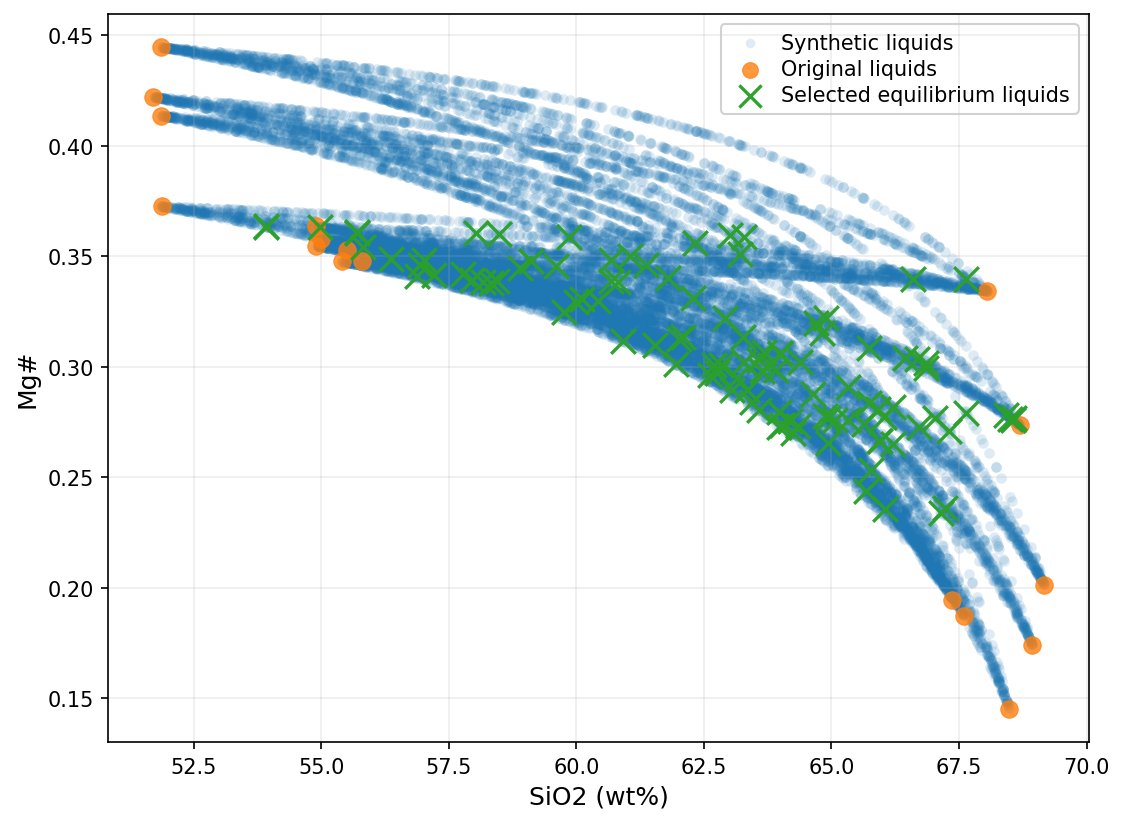

Wrote pairing cache: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\merapi_2010_pairing_err1e-4_n20000_endmembers.xlsx


106

In [13]:
res_10 = pair_mineral_liquid_by_kd_excel_cache(
    CACHE_DIR / "merapi_2010_pairing_err1e-4_n20000_endmembers.xlsx",
    X_mine=cpx_10_input,
    X_liq=liq_2010[liq_cols],     # Defines the expected column set/order.
    one_to_one=True,
    interpolate_liq=True,
    interp_mode="endmembers",
    n_synth=20000,
    endmember1=liq_2010[liq_2010['glass/bulk']=="bulk"][liq_cols], # bulk
    endmember2=liq_2010[liq_2010['glass/bulk']=="glass"][liq_cols], # glass
    random_state=42,
    kd=0.20,
    error=1e-4,
)
paired_cpx_10, paired_liq_10 = res_10.cleaned_minerals, res_10.cleaned_liquids
paired_cpx_10_pass = paired_cpx_10[res_10.pairs_pass_mask].reset_index(drop=True)
paired_liq_10_pass = paired_liq_10[res_10.pairs_pass_mask].reset_index(drop=True)



len(paired_cpx_10_pass)


In [14]:
res_06.pairs[res_06.pairs_pass_mask]["kd_value"]

0     0.200002
1     0.200000
2     0.199997
3     0.200008
4     0.200014
5     0.200001
6     0.199998
7     0.200000
8     0.199999
9     0.200007
10    0.200002
11    0.200006
12    0.199999
13    0.199995
14    0.199997
15    0.199996
16    0.200000
17    0.200003
18    0.200000
19    0.199999
20    0.200001
21    0.199998
22    0.199999
23    0.200001
24    0.200001
25    0.200006
26    0.199999
27    0.199999
28    0.200000
29    0.200002
30    0.200000
31    0.200003
32    0.199997
33    0.199994
34    0.200007
35    0.200000
36    0.200018
37    0.200001
38    0.200000
39    0.199999
40    0.199996
41    0.200000
Name: kd_value, dtype: float64

## 4. Cpx-Liquid Thermobarometry

### Cpx-Liquid Setup

In [15]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_P_06 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_P_10 = workflow_thermobarometry(P_cpx_liq_pool)
    workflow_cpx_liq_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_liq_P_{timestamp}_report.xlsx"

from aims4pt.reporting.excel import report_excel
report_excel(
    workflow_obj=workflow_cpx_liq_P_06,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_P_10,
    model_list =P_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Loading required package: PerformanceAnalytics
  
R callback write-console: Loading required package: xts
  
R callback write-console: Loading required package: zoo
  
R callback write-console: 
Attaching package: 'zoo'

  
R callback write-console: The following objects are masked from 'package:base':

    as.Date, as.Date.numeric

  
R callback write-console: 
Attaching package: 'PerformanceAnalytics'

  
R callback write-console: The following object is masked from 'package:graphics':

    legend

  
R callback write-console: Loading required package: rJava
  
R callback write-console: Loading required package: extraTrees
  
R callback write-console: Loading required package: readxl
  
R callback write-console: Loading required package: EnvStats
  
R callback write-console: 
Attaching package: 'EnvStats'

  
R callback write-console: The foll


Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2006_P_workflow_cpx_liq_P_add_HPS_020.pkl
Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2010_P_workflow_cpx_liq_P_add_HPS_020.pkl


In [16]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_liq_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_liq_T_06 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_liq_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_liq_T_10 = workflow_thermobarometry(T_cpx_liq_pool)
    workflow_cpx_liq_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_liq_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_liq_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_liq_T_06,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_liq_T_10,
    model_list =T_cpx_liq_pool,
    original_data=paired_cpx_10_pass,
    out_path=report_path_2010
)

C:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\src\aims4pt\model_tools\Brugman_Till_19.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_liq.fillna(0, inplace=True)


Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2006_T_workflow_cpx_liq_T_add_HPS_020.pkl


C:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\src\aims4pt\model_tools\Brugman_Till_19.py:156: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_liq.fillna(0, inplace=True)


Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2010_T_workflow_cpx_liq_T_add_HPS_020.pkl


## 5. Cpx-Only Thermobarometry

### Cpx-Only Setup

In [17]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_P_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_P_06 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_P_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_P_10 = workflow_thermobarometry(P_cpx_only_pool)
    workflow_cpx_only_P_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_P_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_P_workflow_cpx_only_P_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_P_workflow_cpx_only_P_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_P_06,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_P_10,
    model_list =P_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2006_P_workflow_cpx_only_P_add_HPS_020.pkl
Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2010_P_workflow_cpx_only_P_add_HPS_020.pkl


In [18]:
import pickle as pkl
paired_liq_06_pass["H2O"] = paired_liq_06_pass['SiO2']*0.06995+0.383
paired_liq_10_pass["H2O"] = paired_liq_10_pass['SiO2']*0.06995+0.383
liq_cols = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', "H2O"]
T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

output_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}.pkl"
output_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}.pkl"

if os.path.exists(output_path_2006):
    import pickle as pkl
    with open(output_path_2006, 'rb') as f:
        workflow_cpx_only_T_06 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2006)
else:
    workflow_cpx_only_T_06 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_06.predict(paired_cpx_06_pass[cpx_cols], paired_liq_06_pass[liq_cols])
    with open(output_path_2006, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_06, f)
    print("Saved workflow to:", output_path_2006)

if os.path.exists(output_path_2010):
    import pickle as pkl
    with open(output_path_2010, 'rb') as f:
        workflow_cpx_only_T_10 = pkl.load(f)
    print("Loaded existing workflow from:", output_path_2010)
else:
    workflow_cpx_only_T_10 = workflow_thermobarometry(T_cpx_only_pool)
    workflow_cpx_only_T_10.predict(paired_cpx_10_pass[cpx_cols], paired_liq_10_pass[liq_cols])
    with open(output_path_2010, 'wb') as f:
        pkl.dump(workflow_cpx_only_T_10, f)
    print("Saved workflow to:", output_path_2010)


report_path_2006 = CACHE_DIR / f"marapi_2006_T_workflow_cpx_only_T_{timestamp}_report.xlsx"
report_path_2010 = CACHE_DIR / f"marapi_2010_T_workflow_cpx_only_T_{timestamp}_report.xlsx"

report_excel(
    workflow_obj=workflow_cpx_only_T_06,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_06_pass,
    out_path=report_path_2006
)
report_excel(
    workflow_obj=workflow_cpx_only_T_10,
    model_list =T_cpx_only_pool,
    original_data=paired_liq_10_pass,
    out_path=report_path_2010
)

Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2006_T_workflow_cpx_only_T_add_HPS_020.pkl
Saved workflow to: c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\.cache\add_HPS_020\marapi_2010_T_workflow_cpx_only_T_add_HPS_020.pkl


## 6. Liquid Thermobarometry

### Data Preparation

In [19]:
glass_mineral  = {
    'ol': 0, #
    'opx': 1,
    'cpx': 1,
    'plag': 1,
    'amph': 1,
    'ox': 1,
    'bt': 0, #
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

whole_rock_mineral_2  = {
    'ol': 1,
    'opx': 1,
    'cpx': 1,
    'plag': 0,
    'amph': 0,
    'ox': 0,
    'bt': 0,
    'ksp': 0,
    'gt': 0,
    'qz': 0
}

glass_mineral_df = pd.DataFrame([glass_mineral])
whole_rock_mineral_df_2 = pd.DataFrame([whole_rock_mineral_2])  


# liq_2006 = liq_raw[liq_raw["Eruption"]==2006].reset_index(drop=True)
# liq_2010 = liq_raw[liq_raw["Eruption"]==2010].reset_index(drop=True)
liq_2006_glass = liq_2006[liq_2006["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2006_bulk = liq_2006[liq_2006["glass/bulk"]=="bulk"].reset_index(drop=True)
liq_2010_glass = liq_2010[liq_2010["glass/bulk"]=="glass"].reset_index(drop=True)
liq_2010_bulk = liq_2010[liq_2010["glass/bulk"]=="bulk"].reset_index(drop=True)



In [20]:
from aims4pt.model_tools.other_models.WandB24_melt import WandB24_melt


### Glass Calculations

In [21]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",4) # 4 is the maximum
P_06_glass = P_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))

P_06_glass

0    2.571405
1    2.617135
2    2.597763
3    2.613756
4    2.385761
5    2.834220
6    2.701609
Name: P_kbar, dtype: float64

In [22]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_glass = P_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))

P_10_glass

0    3.624881
1    4.176075
2    3.883335
3    4.475628
4    3.583497
5    4.521359
6    4.835092
Name: P_kbar, dtype: float64

In [23]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 4)
T_06_glass = T_model.predict(liq_2006_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2006_glass.index))
T_06_glass

0    896.734320
1    895.690263
2    900.823777
3    887.202860
4    912.499878
5    890.807947
6    933.464901
Name: T_C, dtype: float64

In [24]:
T_10_glass = T_model.predict(liq_2010_glass[interested_col], pd.DataFrame([glass_mineral], index=liq_2010_glass.index))
T_10_glass

0    908.453739
1    944.435455
2    905.130439
3    939.026039
4    940.386646
5    928.743372
6    964.146544
Name: T_C, dtype: float64

### Whole-Rock Calculations

In [25]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
P_model = WandB24_melt("P",3)
P_06_bulk = P_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))

P_06_bulk

0    6.282600
1    6.306187
2    6.437876
3    8.125607
4    8.095017
5    9.078031
6    8.298289
Name: P_kbar, dtype: float64

In [26]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']

P_10_bulk = P_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))

P_10_bulk

0    6.530688
1    6.752381
2    6.587118
3    6.815809
4    6.808471
5    6.788134
6    8.125607
7    8.095017
8    9.078031
9    8.298289
Name: P_kbar, dtype: float64

In [27]:
interested_col = ['SiO2', 'TiO2', 'Al2O3', 'FeO', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O']
T_model = WandB24_melt("T", 3)
T_06_bulk = T_model.predict(liq_2006_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2006_bulk.index))
T_06_bulk

0    1055.818273
1    1053.651935
2    1063.067838
3    1098.733966
4    1103.323555
5    1093.859579
6    1091.772572
Name: T_C, dtype: float64

In [28]:
T_10_bulk = T_model.predict(liq_2010_bulk[interested_col], pd.DataFrame([whole_rock_mineral_2], index=liq_2010_bulk.index))
T_10_bulk

0    1061.506121
1    1066.706402
2    1065.909294
3    1077.922585
4    1073.216512
5    1073.105220
6    1098.733966
7    1103.323555
8    1093.859579
9    1091.772572
Name: T_C, dtype: float64

## 7. Merapi Plots and Comparison Figures

### Plotting Setup

In [29]:


df = pd.DataFrame({
    "min km": [1.5, 1.5,2, 0 , 10, 25],
    "max km": [2.5, 2.5,3, 4, 15, 45],
    "uncertainty": [1, 0.5, np.nan, 5, 5, 5],
})

from aims4pt.data_tools.crust import kbar_to_km_multilayer, km_to_kbar_multilayer
densities_kg_m3=[2242, 2900]
layer_boundaries_km=[10]

min_kbar = km_to_kbar_multilayer(df["min km"], densities_kg_m3, layer_boundaries_km)
max_kbar = km_to_kbar_multilayer(df["max km"], densities_kg_m3, layer_boundaries_km)
df["min kbar"] = min_kbar
df["max kbar"] = max_kbar
df

,min km,max km,uncertainty,min kbar,max kbar
0,1.5,2.5,1.0,0.329910,0.549851
1,1.5,2.5,0.5,0.329910,0.549851
2,2.0,3.0,NaN,0.439880,0.659821
3,0.0,4.0,5.0,0.000000,0.879761
4,10.0,15.0,5.0,2.199402,3.621852
5,25.0,45.0,5.0,6.466752,12.156552


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25523 (\N{CJK UNIFIED IDEOGRAPH-63B3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


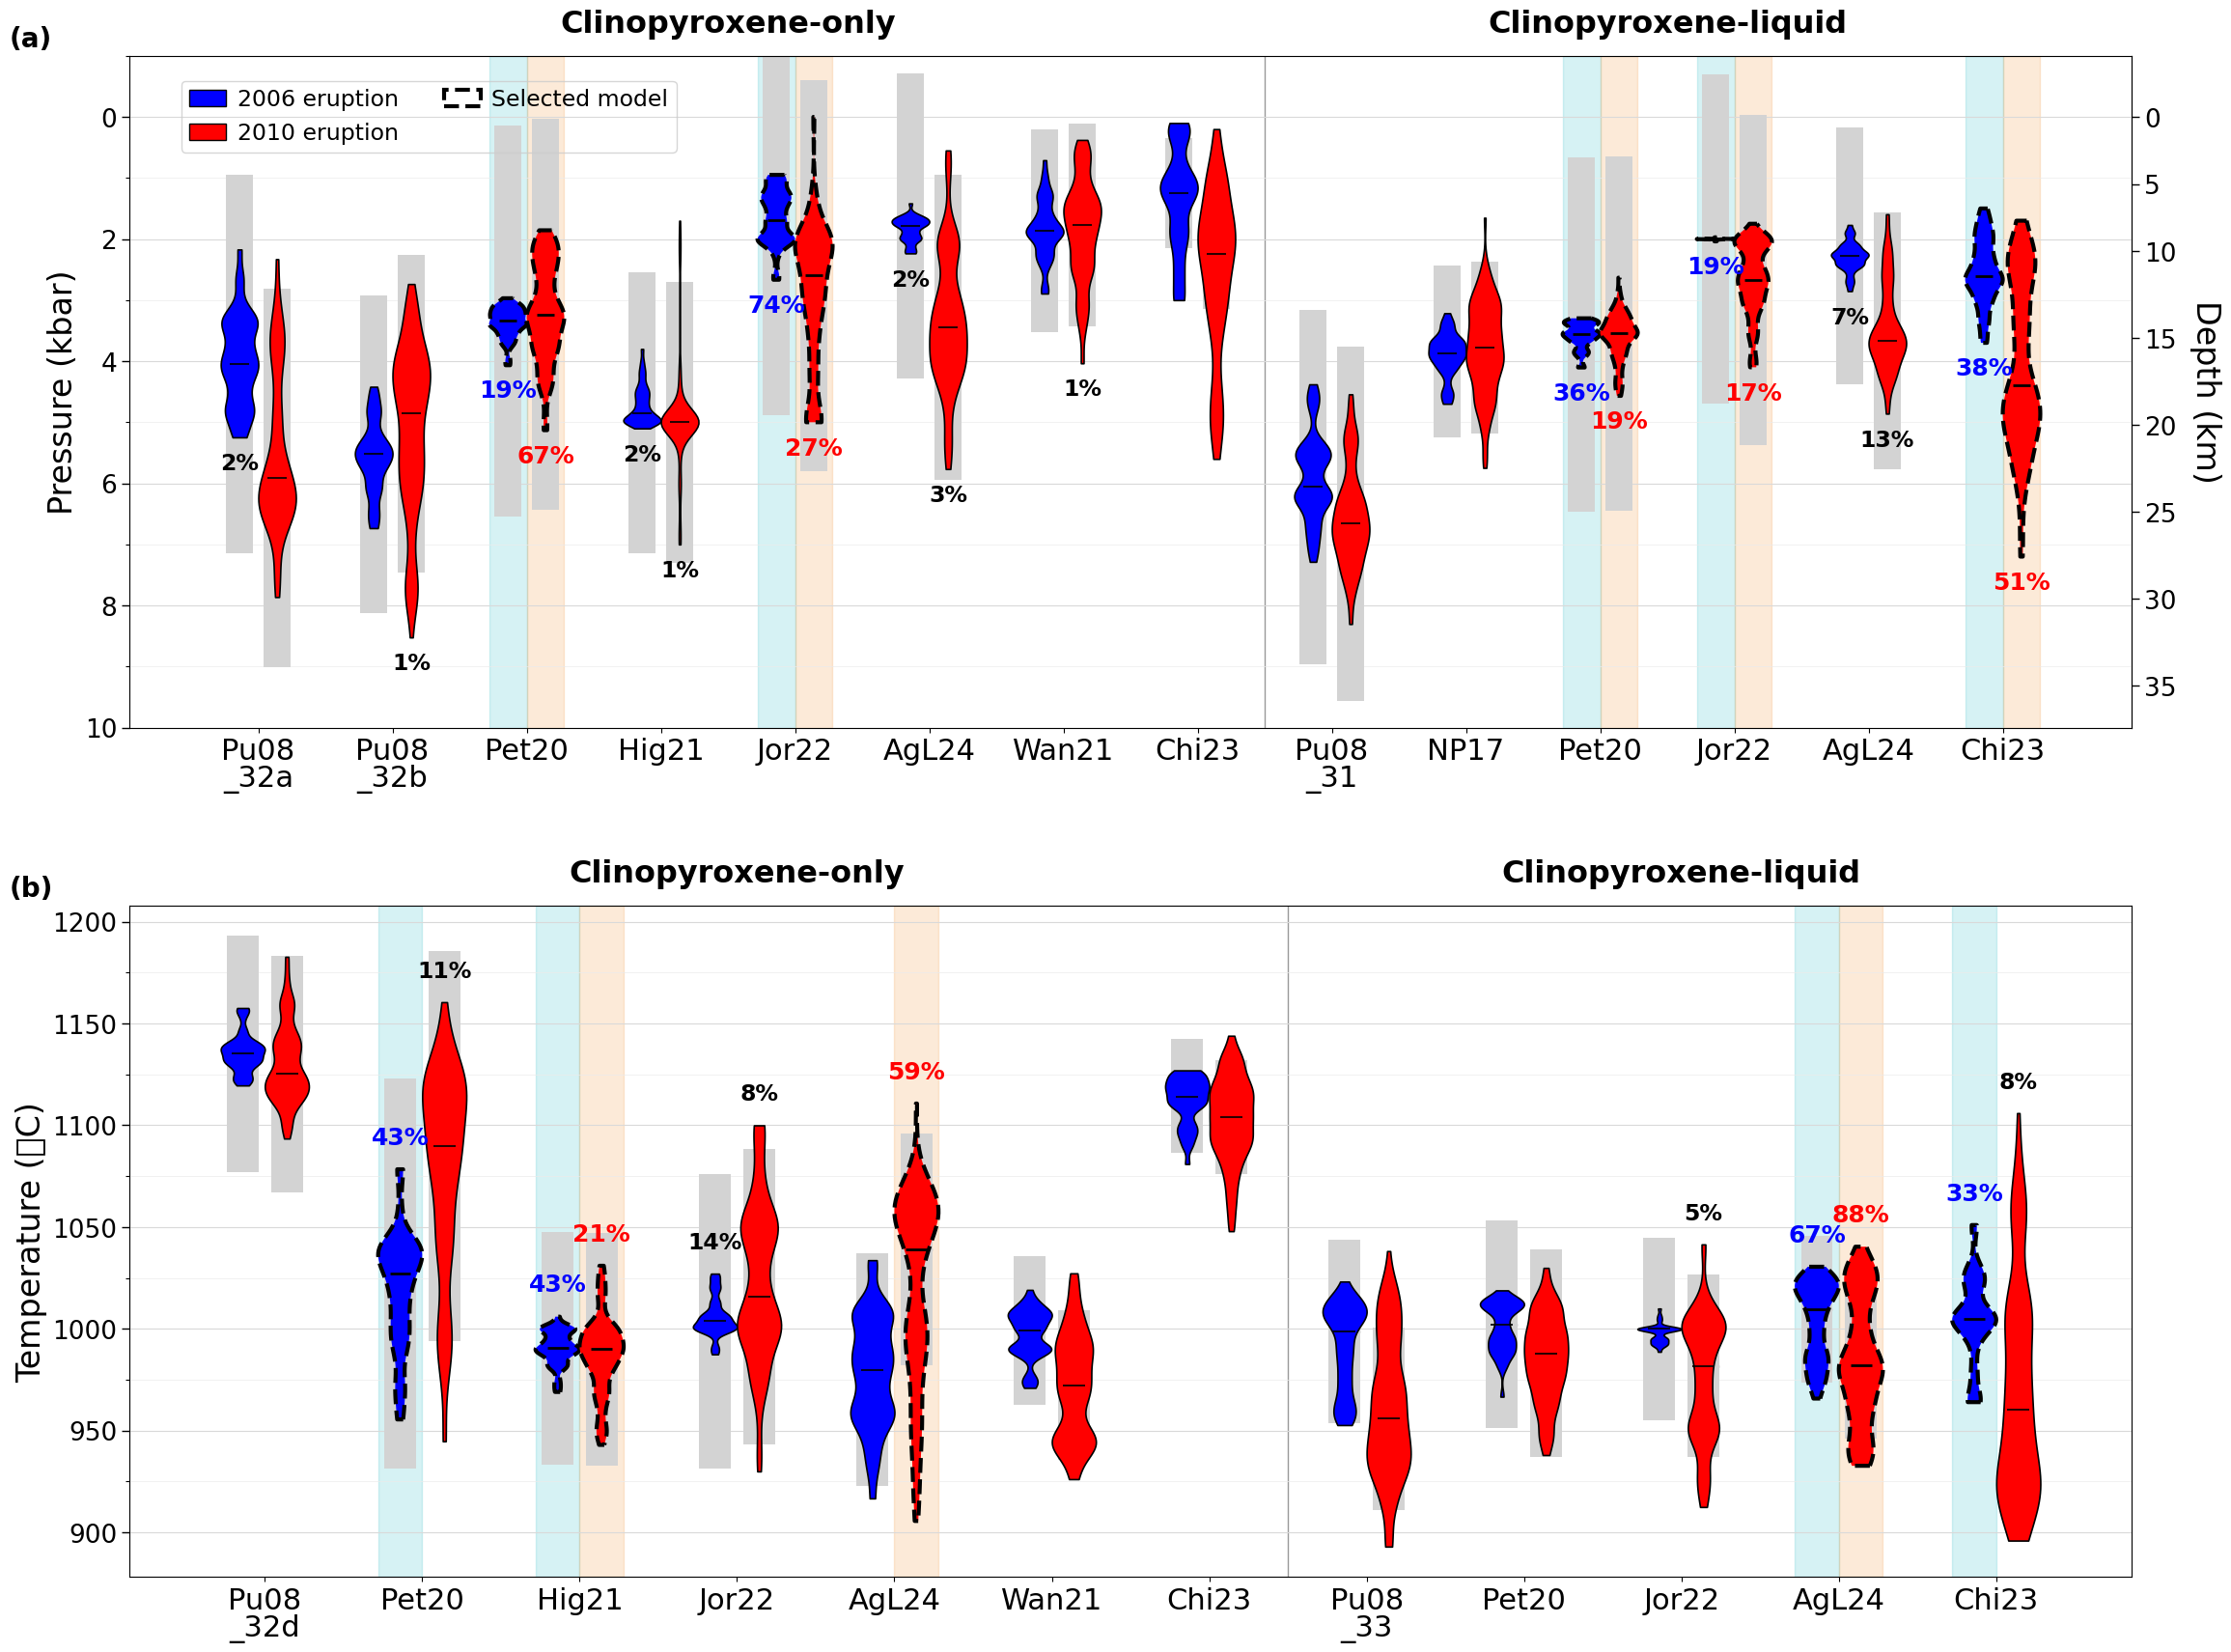

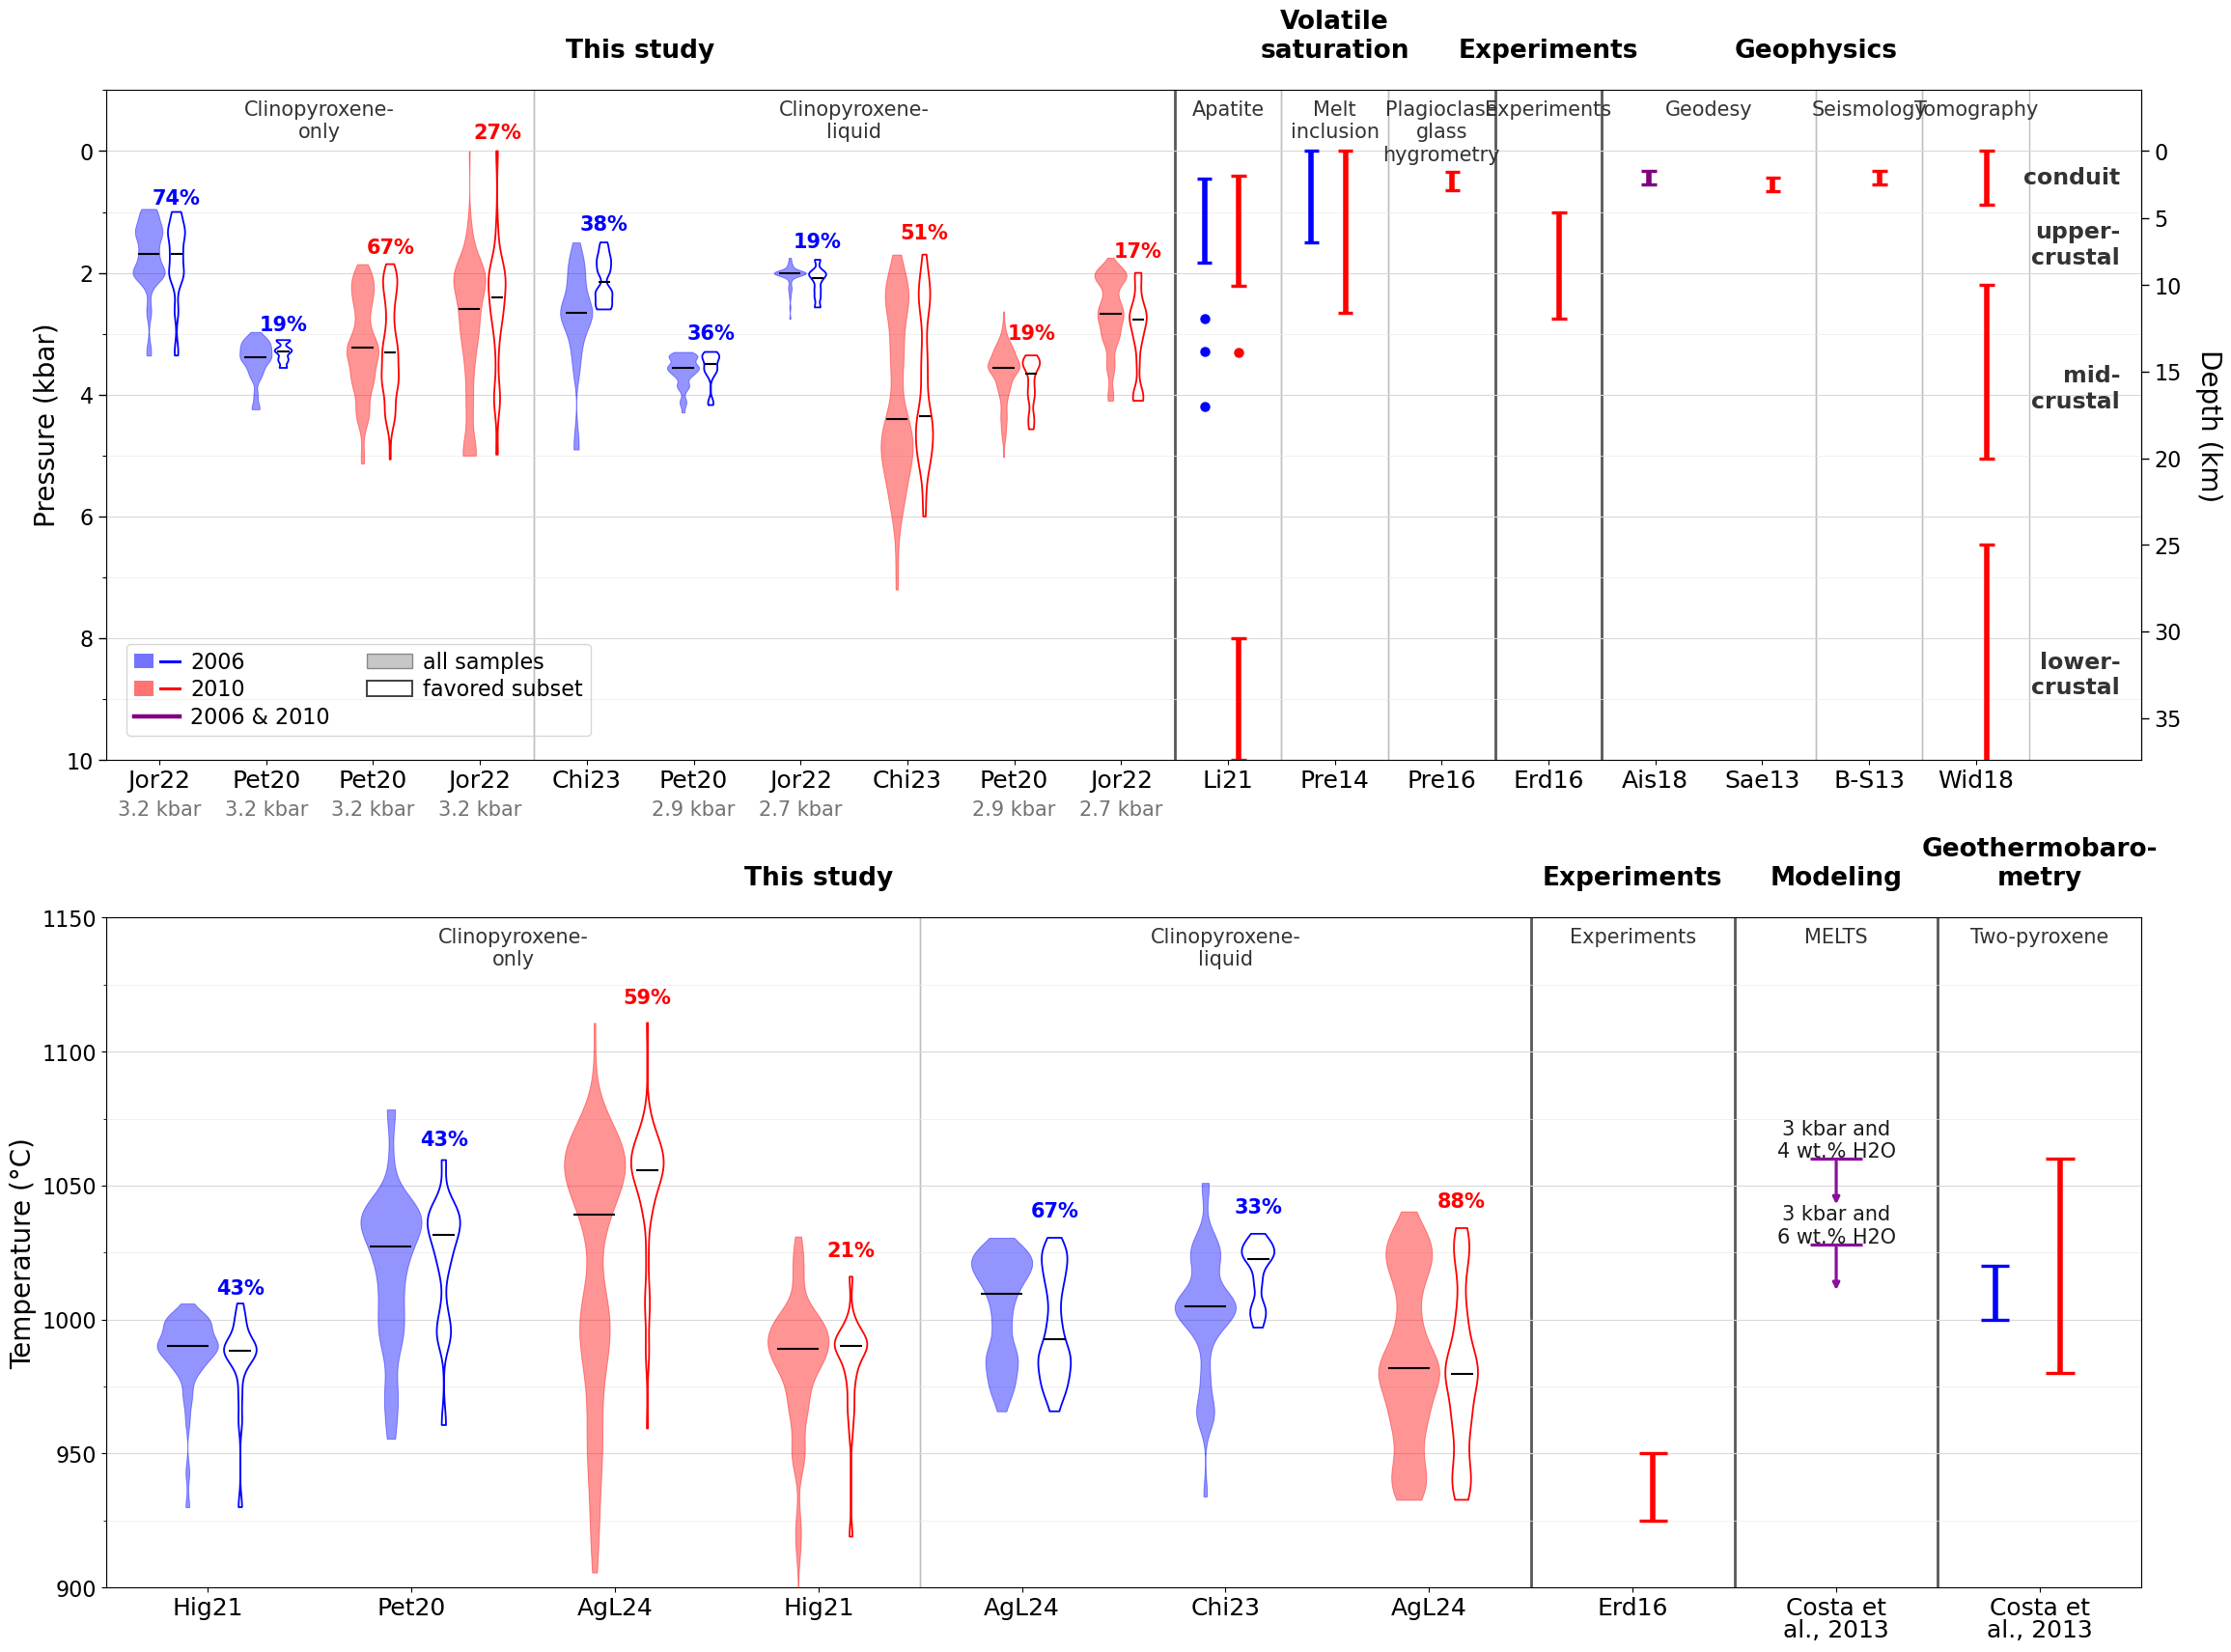

c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\scripts\figure_helpers.py:36: UserWarning: Glyph 25523 (\N{CJK UNIFIED IDEOGRAPH-63B3}) missing from current font.
  fig.savefig(pdf_path, bbox_inches=bbox_inches, **savefig_kwargs)
c:\Users\13493\Documents\PROJECTS\Cpx_thermobarometry_recommend_202507\code\AIMS4PT\paper\scripts\figure_helpers.py:37: UserWarning: Glyph 25523 (\N{CJK UNIFIED IDEOGRAPH-63B3}) missing from current font.
  fig.savefig(png_path, dpi=dpi, bbox_inches=bbox_inches, **savefig_kwargs)


(WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_sX_Merapi_different_constraints_HPS_liq_v2.pdf'),
 WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.images/fig_sX_Merapi_different_constraints_HPS_liq_v2.png'))

c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 25523 (\N{CJK UNIFIED IDEOGRAPH-63B3}) missing from current font.
  func(*args, **kwargs)


In [30]:

from aims4pt.model_tools.ModelManager import ModelManager
from paper.scripts.merapi_helpers import (
    ThermobarometryWorkflowBundle,
    plot_ranked_thermobarometry_literature_comparison,
    plot_ranked_thermobarometry_summary,
)
from paper.scripts.figure_helpers import save_figure_pdf_png

T_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_T.xlsx")
P_LIT_PATH = os.path.join(DATA_DIR, "merapi_literature_P.xlsx")

P_lit_raw = pd.read_excel(P_LIT_PATH)
T_lit_raw = pd.read_excel(T_LIT_PATH)
P_lit_raw = P_lit_raw[P_lit_raw["plot"] == True].reset_index(drop=True)
T_lit_raw = T_lit_raw[T_lit_raw["plot"] == True].reset_index(drop=True)

densities_kg_m3 = [2242, 2900]
layer_boundaries_km = [10]


def _get_model_name(pool, T_P, cpx_only, aliases):
    """Return the model_name for the first matching alias."""
    for alias in aliases:
        model = ModelManager.get_model(
            pool,
            model_name=alias,
            T_P=T_P,
            cpx_only=cpx_only,
            exact=False,
            raise_if_empty=False,
        )
        if model is not None:
            return model.model_name
    raise ValueError(f"No model matched aliases: {aliases}")


def _get_model_names(pool, T_P, cpx_only, alias_groups):
    return [_get_model_name(pool, T_P, cpx_only, aliases) for aliases in alias_groups]


T_cols_liq = _get_model_names(
    T_model_pool,
    "T",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)
P_cols_liq = _get_model_names(
    P_model_pool,
    "P",
    False,
    [
        ["Putirka, 2008 eq33_T; eq31_P"],
        ["Neave & Putirka"],
        ["Petrelli"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Chicchi"],
    ],
)

P_cols_only = _get_model_names(
    P_model_pool,
    "P",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Putirka, 2008 eq32d_T; eq32b_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)
T_cols_only = _get_model_names(
    T_model_pool,
    "T",
    True,
    [
        ["Putirka, 2008 eq32d_T; eq32a_P"],
        ["Petrelli"],
        ["Higgins"],
        ["Jorgenson"],
        ["Ágreda-López", "Agreda", "greda"],
        ["Wang"],
        ["Chicchi"],
    ],
)

cpx_only = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_only_P_06,
    pressure_2010=workflow_cpx_only_P_10,
    temperature_2006=workflow_cpx_only_T_06,
    temperature_2010=workflow_cpx_only_T_10,
)

cpx_liq = ThermobarometryWorkflowBundle(
    pressure_2006=workflow_cpx_liq_P_06,
    pressure_2010=workflow_cpx_liq_P_10,
    temperature_2006=workflow_cpx_liq_T_06,
    temperature_2010=workflow_cpx_liq_T_10,
)

liquid_results = {
    "P": {
        "2006": {"glass": P_06_glass, "bulk": P_06_bulk},
        "2010": {"glass": P_10_glass, "bulk": P_10_bulk},
    },
    "T": {
        "2006": {"glass": T_06_glass, "bulk": T_06_bulk},
        "2010": {"glass": T_10_glass, "bulk": T_10_bulk},
    },
}

# 2010 reservoir depth ranges. These values are explicit for easy later editing.
MERAPI_2010_RESERVOIR_BANDS = [
    {
        "label": "conduit",
        "min_depth_km": 0,
        "max_depth_km": 4,
        "color": "#EEDBB5",
        "alpha": 0.22,
    },
    {
        "label": "upper-\ncrustal",
        "min_depth_km": 4,
        "max_depth_km": 10,
        "color": "#DEBB7C",
        "alpha": 0.24,
        "hatch": "///",
        "edgecolor": "#938564",
        "linestyle": "--",
    },
    {
        "label": "mid-\ncrustal",
        "min_depth_km": 13,
        "max_depth_km": 19,
        "color": "#E9A382",
        "alpha": 0.22,
    },
    {
        "label": "lower-\ncrustal",
        "min_depth_km": 25,
        "max_depth_km": 40,
        "color": "#E6827C",
        "alpha": 0.22,
    },
]

figs = plot_ranked_thermobarometry_summary(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    liquid_results=None,
    pressure_ylim=(-1, 10),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    this_study_figsize=(23.0, 17.0),
    this_study_subplot_hspace=0.08,
    literature_figsize=(23, 17.0),
    show=True,
    use_model_abbreviations=True,
    literature_include_temperature=True,
    literature_panel_labels=(),
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    this_study_tick_labelsize=19,
    this_study_model_tick_labelsize=22,
    split_literature_legend=True,
    literature_legend_bbox_to_anchor=(0.47, 0.09),
    literature_model_tick_labelsize=18,
    literature_reservoir_label_x_offset=1.35,
    literature_reservoir_label_right_margin=0.20,
)
save_figure_pdf_png(figs["this_study"][0], IMAGES_DIR, "fig_sX_Merapi_P_T_pre-2006_liq_v2")
save_figure_pdf_png(figs["literature_comparison"][0], IMAGES_DIR, "fig_sX_Merapi_different_constraints_pre-2006_liq_v2")


In [31]:

fig_s9, axes_s9 = plot_ranked_thermobarometry_literature_comparison(
    cpx_only,
    cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_literature=P_lit_raw,
    temperature_literature=T_lit_raw,
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    liquid_results=liquid_results,
    pressure_ylim=(-1, 10),
    temperature_ylim = (800, 1150),
    densities_kg_m3=densities_kg_m3,
    layer_boundaries_km=layer_boundaries_km,
    literature_pressure_source="auto",
    figsize=(20.0, 17.0),
    use_model_abbreviations=True,
    pressure_reservoir_bands=MERAPI_2010_RESERVOIR_BANDS,
    split_literature_legend=True,
    literature_legend_bbox_to_anchor=(0.56, 0.48),
)
save_figure_pdf_png(
    fig_s9,
    IMAGES_DIR,
    "fig_s_Merapi_different_constraints_with_liquid_thermobarometer",
)

plt.show()


C:\Users\13493\AppData\Local\Temp\ipykernel_40912\2650526622.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# compare original vs +pre-2006 for cpx-only and cpx-liq
 



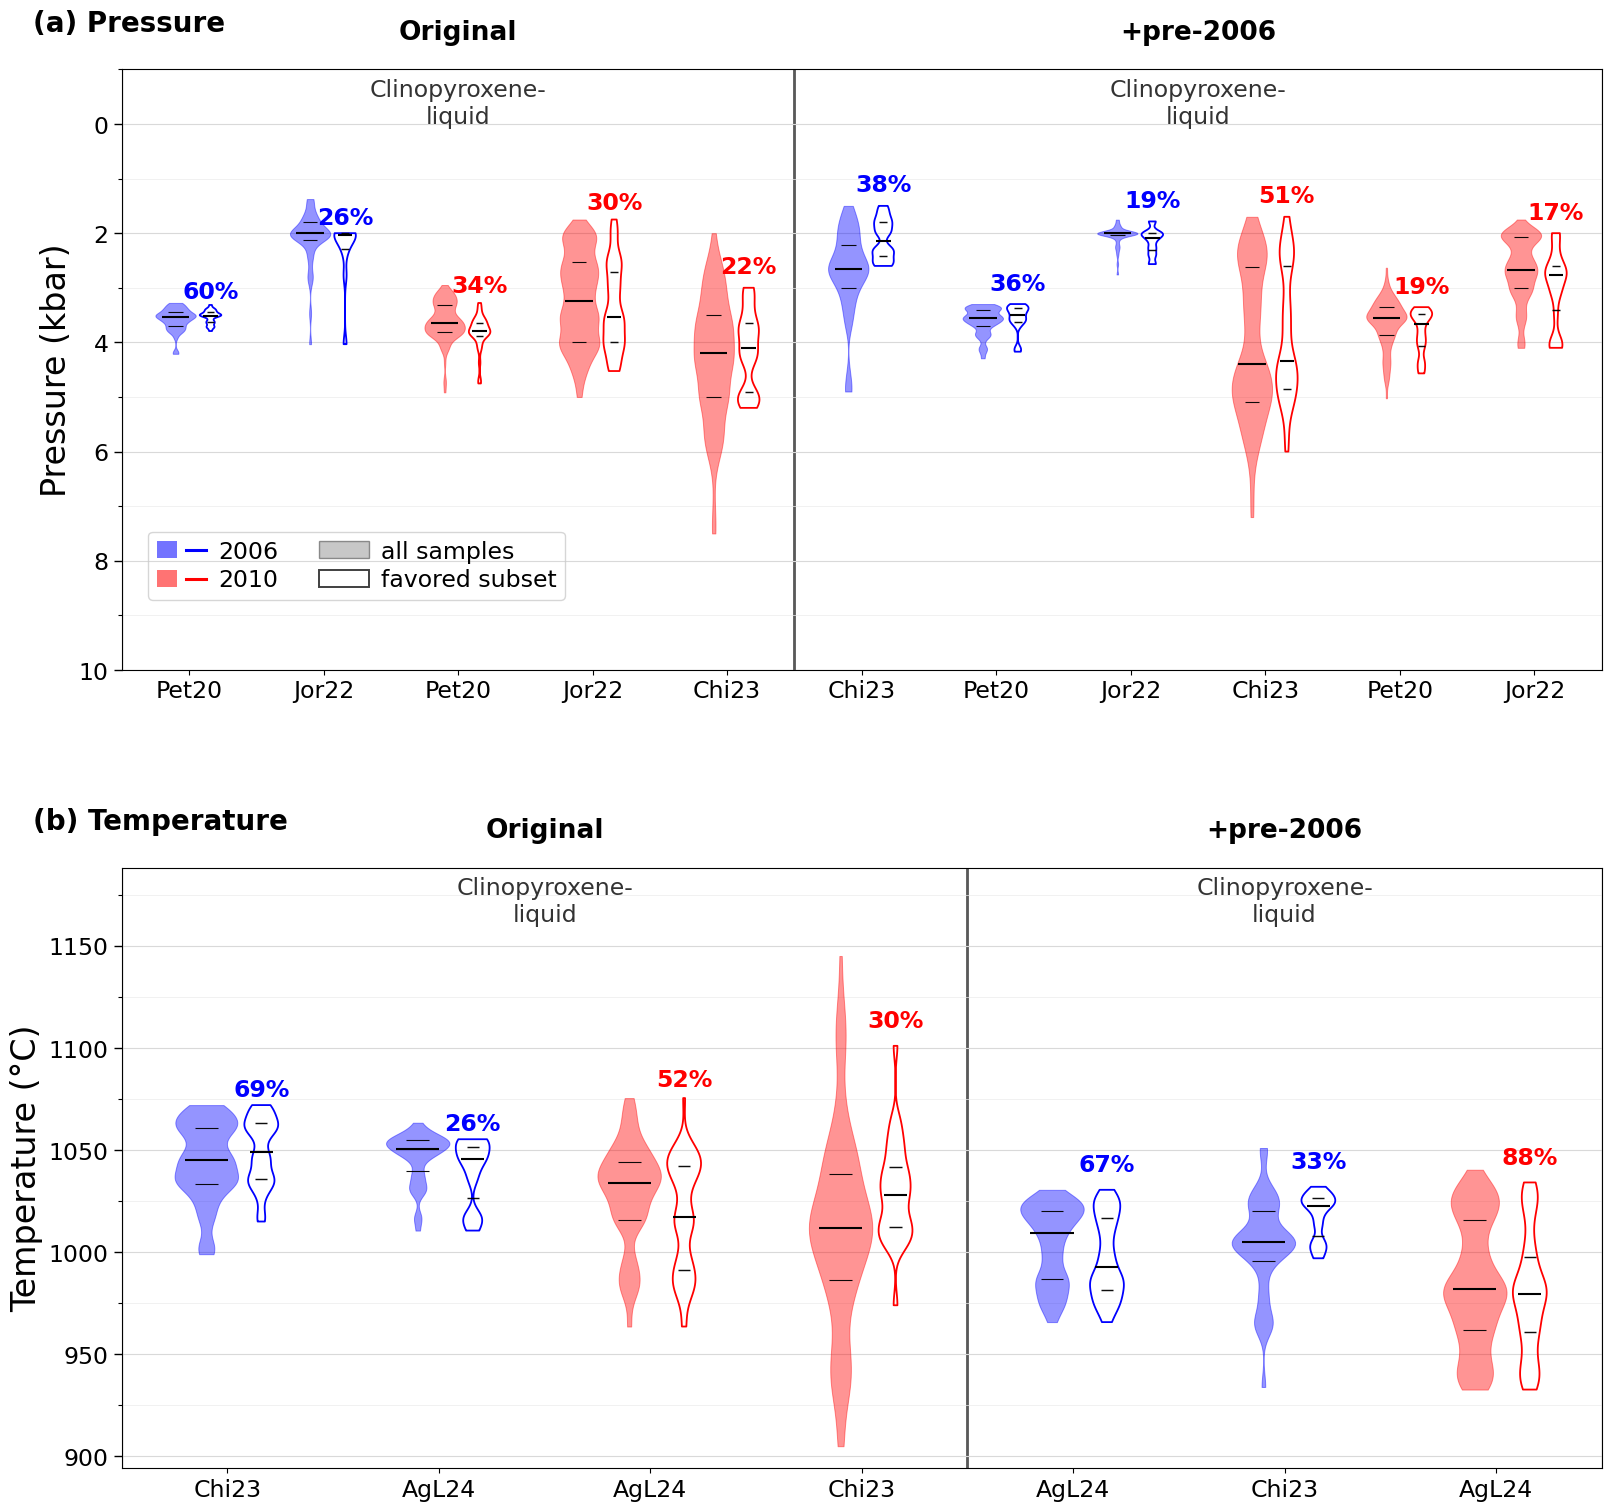

In [34]:
import pickle as pkl

from paper.scripts.merapi_helpers import (
    ThermobarometryWorkflowBundle,
    plot_ranked_thermobarometry_original_vs_pre_2006_comparison,
)

ORIGINAL_TIMESTAMP = "add_pre-2006_028"
PRE_2006_TIMESTAMP = "add_pre-2006_020"


def _load_merapi_workflow(year, kind, phase_type, timestamp):
    # Load local workflow caches without modifying them.
    cache_path = PAPER_DIR / ".cache" / timestamp / f"marapi_{year}_{kind}_workflow_{phase_type}_{kind}_{timestamp}.pkl"
    with open(cache_path, "rb") as file_obj:
        return pkl.load(file_obj)


def _load_merapi_workflow_bundle(phase_type, timestamp):
    return ThermobarometryWorkflowBundle(
        pressure_2006=_load_merapi_workflow("2006", "P", phase_type, timestamp),
        pressure_2010=_load_merapi_workflow("2010", "P", phase_type, timestamp),
        temperature_2006=_load_merapi_workflow("2006", "T", phase_type, timestamp),
        temperature_2010=_load_merapi_workflow("2010", "T", phase_type, timestamp),
    )


original_cpx_only = _load_merapi_workflow_bundle("cpx_only", ORIGINAL_TIMESTAMP)
original_cpx_liq = _load_merapi_workflow_bundle("cpx_liq", ORIGINAL_TIMESTAMP)
pre_2006_cpx_only = _load_merapi_workflow_bundle("cpx_only", PRE_2006_TIMESTAMP)
pre_2006_cpx_liq = _load_merapi_workflow_bundle("cpx_liq", PRE_2006_TIMESTAMP)

fig_original_vs_pre_2006, axes_original_vs_pre_2006 = plot_ranked_thermobarometry_original_vs_pre_2006_comparison(
    original_cpx_only,
    original_cpx_liq,
    pre_2006_cpx_only,
    pre_2006_cpx_liq,
    pressure_columns={"cpx_only": P_cols_only, "cpx_liq": P_cols_liq},
    temperature_columns={"cpx_only": T_cols_only, "cpx_liq": T_cols_liq},
    pressure_model_pool=P_model_pool,
    temperature_model_pool=T_model_pool,
    pressure_ylim=(-1, 10),
    figsize=(16.0, 15.0),
    use_model_abbreviations=True,
    panel_labels=("(a) Pressure", "(b) Temperature"),
)

save_figure_pdf_png(
    fig_original_vs_pre_2006,
    IMAGES_DIR,
    "fig_s16_Merapi_original_vs_pre-2006_P_T_this_study",
    dpi=600,
    bbox_inches="tight",
)
fig_original_vs_pre_2006
